# Drift-Diffusion Model (DDM)

## Safe-vs-Risky Economic Choice - Wiener First-Passage-Time Model

This example demonstrates parameter recovery for a drift-diffusion model (DDM) of a
safe-vs-risky economic choice task. On each trial the agent chooses between a **SAFE**
bet (a certain, fixed amount `safe`) and a **RISKY** bet (a gamble that pays `payoff`
with probability `p`, so its expected value is `EV_risky = p * payoff`). We jointly
model *which* option was chosen (`choice`) **and** *how long* it took (`rt`).

Evidence accumulates as a Wiener diffusion between two absorbing boundaries:

- **upper** boundary (at $a$) $\rightarrow$ choose **RISKY** (`choice = 1`)
- **lower** boundary (at $0$) $\rightarrow$ choose **SAFE** (`choice = 0`)
- the accumulator starts at $z\,a$ (relative bias $z \in (0,1)$) with unit noise.

The drift rate on a trial is driven by the risky-minus-safe value difference, so a
positive drift pushes the accumulator toward the RISKY (upper) boundary:

$$
v = v_{\text{coef}} \cdot (\text{EV}_{\text{risky}} - \text{safe}),
\qquad \text{EV}_{\text{risky}} = p \cdot \text{payoff} \tag{1}
$$

### Likelihood: Navarro & Fuss (2009) WFPT

The response-time density for absorption at the **lower** boundary is the Wiener
first-passage-time (WFPT) density. Following Navarro & Fuss (2009), it factorizes into
a drift/scale term times the first-passage density of the *driftless*, unit-separation
process in normalized time $\tau = t / a^2$:

$$
p(t \mid v, a, z) = \frac{1}{a^2}\, e^{-v a z - v^2 t / 2}\; f\!\left(\tau \mid z\right) \tag{2}
$$

$f(\tau \mid z)$ has two convergent series; we evaluate whichever needs fewer terms to
reach tolerance (Navarro & Fuss term-count bounds), all in **log space**:

$$
\textbf{small-}\tau:\quad
f = (2\pi\tau^3)^{-1/2}\sum_{k=-\infty}^{\infty} (z+2k)\, e^{-(z+2k)^2 / (2\tau)} \tag{3}
$$

$$
\textbf{large-}\tau:\quad
f = \pi \sum_{k=1}^{\infty} k\, e^{-k^2 \pi^2 \tau / 2}\, \sin(k\pi z) \tag{4}
$$

The **upper**-boundary density (a RISKY choice) follows from the Wiener reflection
$v \to -v$, $z \to 1-z$. The observed RT includes a non-decision time $t_0$, so the
diffusion density is evaluated at the decision time $t = \text{rt} - t_0$.

**Free parameters:** drift scaling $v_{\text{coef}}$, boundary separation $a$,
non-decision time $t_0$, and start-point bias $z$.

In [1]:
import os
os.environ.setdefault("PYTHONWARNINGS", "ignore")
import warnings
from scipy.optimize import OptimizeWarning
# Nelder-Mead ignores the harness's default BFGS options (gtol/eps); silence that noise
warnings.filterwarnings("ignore", category=OptimizeWarning)

import numpy as np
from pyem import EMModel
from pyem.models.ddm import ddm_model, wfpt_logpdf
import sys; sys.path.insert(0, ".")  # so `from params import build_params` works when run from examples/
from params import build_params

# ModelSpec bundles this model's identity, description, and sim/fit entry points
print(f"Model ID   : {ddm_model.id}")
print(f"Description: {ddm_model.desc}")
print(f"Spec       : {ddm_model.spec}")

Model ID   : ddm
Description: Drift-diffusion model (DDM) of a safe-vs-risky economic choice.
Each trial pits a SAFE certain amount against a RISKY gamble (EV = p*payoff);
both the choice and the response time are modelled by a two-boundary Wiener
diffusion (upper = risky, lower = safe; start = z*a). Drift is driven by the
risky-minus-safe value difference: v = v_coef * (EV_risky - safe). The
likelihood is the Navarro & Fuss (2009) first-passage-time density evaluated in
log space at the decision time rt - t0.
Free parameters: v_coef (drift scaling), a (boundary separation),
t0 (non-decision time), z (start-point bias).
Spec       : {'ddm': {'drift': ['v_coef'], 'boundary': ['a'], 'ndt': ['t0'], 'bias': ['z']}, 'likelihood': 'navarro_fuss_2009_wfpt', 'boundaries': {'upper': 'risky', 'lower': 'safe'}}


### Sanity check: the WFPT log-density matches a fine-grid numerical reference

Before fitting, we confirm `wfpt_logpdf` (which adaptively selects the small-/large-time
series) agrees with an independent large-time-series reference summed to many terms.

In [2]:
def numerical_logdens(rt, v, a, z, nterms=5000):
    """Independent large-time-series reference for the lower-boundary density."""
    k = np.arange(1, nterms + 1)
    s = np.sum(k * np.exp(-(k**2) * np.pi**2 * rt / (2 * a**2)) * np.sin(k * np.pi * z))
    return np.log(np.pi / (a**2) * np.exp(-v * a * z - v**2 * rt / 2.0) * s)

for (rt, v, a, z) in [(0.5, 1.0, 1.2, 0.5), (0.15, 2.0, 0.8, 0.3), (2.5, 0.2, 1.5, 0.45)]:
    got, ref = wfpt_logpdf(rt, v, a, z), numerical_logdens(rt, v, a, z)
    print(f"rt={rt:<4} v={v:<5} a={a:<4} z={z:<5} | wfpt={got:+.6f}  ref={ref:+.6f}  |diff|={abs(got-ref):.2e}")

rt=0.5  v=1.0   a=1.2  z=0.5   | wfpt=-1.783390  ref=-1.783390  |diff|=2.22e-16
rt=0.15 v=2.0   a=0.8  z=0.3   | wfpt=-0.486788  ref=-0.486788  |diff|=5.55e-17
rt=2.5  v=0.2   a=1.5  z=0.45  | wfpt=-5.346702  ref=-5.346702  |diff|=8.88e-16


In [3]:
# simulate computer agents completing the safe-vs-risky DDM task
nsubjects, ntrials = 70, 150

# generate "true" parameters using the shared parameter registry (examples/params.py)
param_names, param_xform, true_params = build_params(
    ["v_coef", "a", "t0", "z"], nsubjects, rng=np.random.default_rng(0)
)

Pearson r [v_coef ] = 0.955
Pearson r [a      ] = 0.978
Pearson r [t0     ] = 0.977
Pearson r [z      ] = 0.972


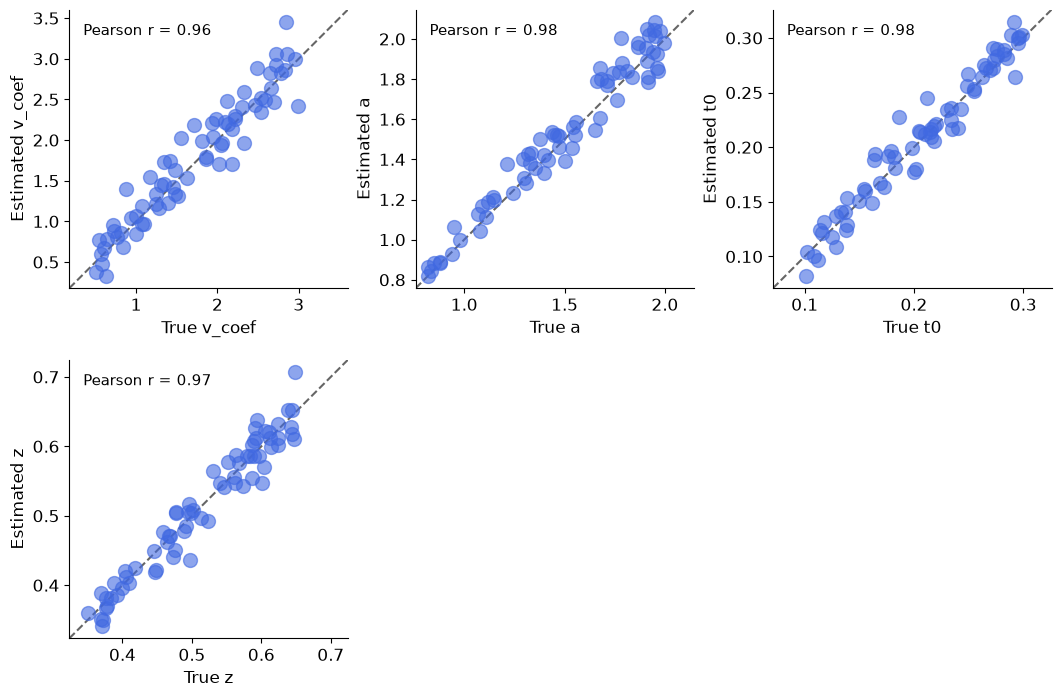

In [4]:
# use EMModel.recover to run simulation, fitting and recovery metrics.
# The WFPT likelihood is mildly non-smooth (series-selection + underflow floor), so we
# fit with the derivative-free Nelder-Mead optimizer rather than BFGS.
model = EMModel(all_data=None, fit_func=ddm_model.fit,
                param_names=param_names,
                param_xform=param_xform,
                simulate_func=ddm_model.sim)

recovery = model.recover(true_params,
                         pr_inputs=["rt", "choice", "ev_risky", "safe"],
                         ntrials=ntrials,
                         fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": -1,
                                     "optim_method": "Nelder-Mead", "max_restarts": 4,
                                     "optim_options": {"maxiter": 3000,
                                                       "xatol": 1e-5, "fatol": 1e-5}})

# scatter plot of recovered parameters
fig = model.plot_recovery(recovery, show=False)
for name, r in zip(param_names, recovery["correlation"]):
    print(f"Pearson r [{name:7s}] = {r:.3f}")

The recovery dictionary also contains numerical summaries such as `recovery['correlation']`, which provides a Pearson correlation coefficient for each parameter (here: `v_coef`, `a`, `t0`, `z`).

In [5]:
# require successful recovery (r > 0.5) for all four DDM parameters
corr = recovery["correlation"]
assert all(c > 0.5 for c in corr), f"parameter recovery below threshold: {dict(zip(param_names, corr))}"
print("All four DDM parameters recovered with r > 0.5:",
      {n: round(float(c), 3) for n, c in zip(param_names, corr)})

All four DDM parameters recovered with r > 0.5: {'v_coef': 0.955, 'a': 0.978, 't0': 0.977, 'z': 0.972}
